# Graphics

In [18]:
import sys
from pathlib import Path

# Jupyter has no __file__ to anchor a relative import on, and the notebook's
# kernel env may not have the package installed -> add the repo root by hand.
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import nd_phase_unwrap.io as io
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn # For visualization of pandas df
import dabest

## 4D Phantom

### Heatmap

In [19]:
data_path = REPO_ROOT / 'test_data'
in_path = data_path / '3+1D_phantom'
out_paths = {
    'IGC': data_path / 'IGC_unwrapped',
    'Laplace': data_path / 'Laplace_unwrapped',
    'ROMEO': data_path / 'ROMEO_unwrapped',
}
# 0 wraps == ground truth (div_factor = 1 + 2*0 leaves the phase untouched)
truth_path = in_path / "0wraps.npy"

truth_array = np.angle(io.load_numpy_data(truth_path))
mask = (np.abs(truth_array) != 0).astype(bool)

# save results in dataframe
row_indices = list(range(6))
col_indices = list(np.arange(1.0, 3.5, 0.5)) + ["no noise"]

heatmaps = {}
for algorithm, out_path in out_paths.items():
    heatmap_df = pd.DataFrame(np.nan, index=row_indices, columns=col_indices)
    heatmap_df.columns.name = "VNR"
    heatmap_df.index.name = "wraps"

    for file in os.listdir(in_path):
        file = Path(file)
        if not file.name.endswith(".npy"):
            continue
        if "VNR" in file.stem:
            vnr = float(file.stem[-3:].replace("_", "."))
        else:
            vnr = "no noise"
        wrapcount = int(file.stem[0])
        div_factor = 1 + 2*wrapcount

        unwrapped_path = out_path / f'{file.stem}_unwrapped.npy'
        if not unwrapped_path.is_file():
            continue
        out_array = io.load_numpy_data(unwrapped_path) / div_factor

        diff = np.abs(truth_array - out_array) < 1.5*np.pi / div_factor
        heatmap_df.at[wrapcount, vnr] = diff[mask].mean()

    heatmaps[algorithm] = heatmap_df


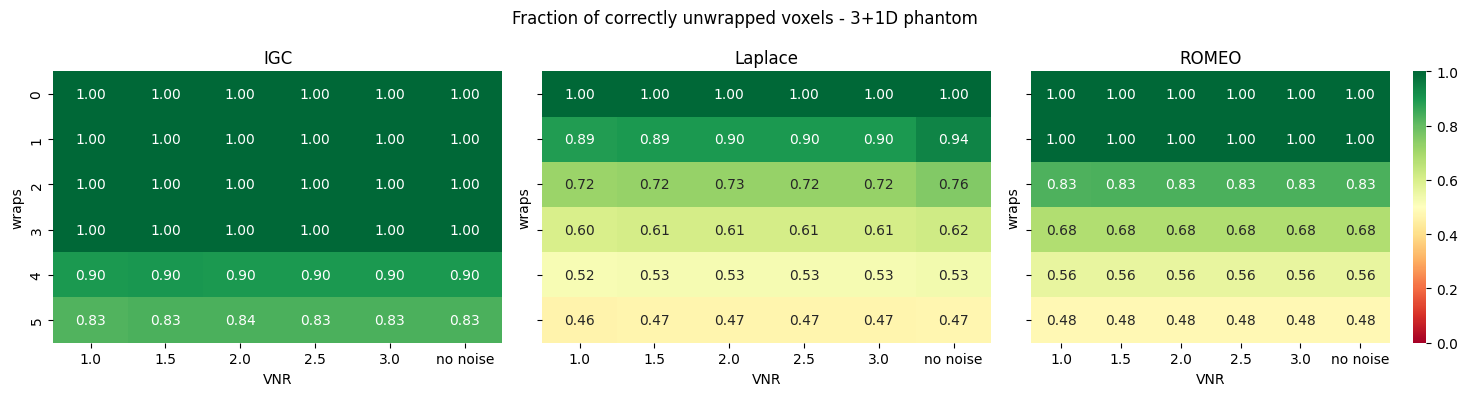

In [20]:
fig, axes = plt.subplots(1, len(heatmaps), figsize=(5 * len(heatmaps), 4), sharey=True)

for axis, (algorithm, heatmap_df) in zip(axes, heatmaps.items()):
    sn.heatmap(heatmap_df, annot=True, fmt='.2f', vmin=0.0,
               cmap='RdYlGn', cbar=axis is axes[-1], ax=axis)
    axis.set_title(algorithm)

fig.suptitle('Fraction of correctly unwrapped voxels - 3+1D phantom')
fig.tight_layout()
# Save fig
# fig.savefig(data_path / '3+1D_phantom_heatmap.png', dpi=150)

## RACLETTE data

`raclette_eval_streaming.csv` holds one row per (subject, VNR, wrap count, algorithm) with the
raw voxel tallies instead of pre-aggregated fractions:

| column | meaning |
| --- | --- |
| `rawdata_name` | subject id (60 subjects) |
| `VNR` | velocity-to-noise ratio, 1.0 ... 5.0, or `no noise` |
| `wraps` | number of induced wraps, 0 ... 5 |
| `algorithm` | `IGC`, `Laplace`, `ROMEO`, or `unprocessed` (the wrapped input = baseline) |
| `total_size` / `mask_size` | voxels in the volume / inside the mask |
| `n_correct` / `n_incorrect` | masked voxels unwrapped (in)correctly; they sum to `mask_size` |

The baseline is only evaluated noise-free, once per (subject, wrap count), so every algorithm
cell is compared against the noise-free wrapped input of the same subject and wrap count.

In [ ]:
raclette_dir = data_path / 'raclette_eval'
BASELINE = 'unprocessed'

raw = pd.read_csv(raclette_dir / 'raclette_eval_streaming.csv').rename(
    columns={'rawdata_name': 'subject', 'VNR': 'vnr', 'wraps': 'num_wraps'})
raw['correct_fraction'] = raw.n_correct / raw.mask_size

# algorithm rows carry a numeric VNR; the baseline rows are the 'no noise' ones
cases = raw[raw.algorithm != BASELINE].copy()
cases['vnr'] = cases.vnr.astype(float)

algorithms = sorted(cases.algorithm.unique())
vnr_levels = sorted(float(v) for v in cases.vnr.unique())
wraps_levels = sorted(int(w) for w in cases.num_wraps.unique())

# 0 wraps needs no unwrapping (correct_fraction == 1) -> drop it from the baseline
baseline = (raw[(raw.algorithm == BASELINE) & (raw.num_wraps.isin(wraps_levels))]
            .set_index(['subject', 'num_wraps'])['correct_fraction']
            .rename('baseline_fraction'))

cases = cases.join(baseline, on=['subject', 'num_wraps'])
# fraction of the initially wrong voxels that the algorithm fixed (<0 -> it made things worse)
cases['improvement'] = ((cases.correct_fraction - cases.baseline_fraction)
                        / (1 - cases.baseline_fraction))

print(f'{cases.subject.nunique()} subjects, wraps {wraps_levels}, VNR {vnr_levels}')
cases.groupby(['algorithm', 'num_wraps'])[['correct_fraction', 'improvement']].mean().unstack(0)

### Heatmap - correctly unwrapped fraction

In [ ]:
base_pivot = (baseline.reset_index().groupby('num_wraps')['baseline_fraction']
              .mean().to_frame('no noise'))
base_pivot.index.name = 'wraps'

fig, axes = plt.subplots(1, len(algorithms) + 1, figsize=(5.5 * len(algorithms) + 2.5, 4),
                         sharey=True,
                         gridspec_kw={'width_ratios': [0.45] + [1] * len(algorithms)})
annot_kws = {'fontsize': 7}

sn.heatmap(base_pivot, annot=True, fmt='.3f', vmin=0.5, vmax=1.0, cmap='RdYlGn',
           cbar=False, ax=axes[0], annot_kws=annot_kws)
axes[0].set_title('wrapped (no unwrapping)')
axes[0].set_xlabel('VNR')

for axis, algo in zip(axes[1:], algorithms):
    pivot = cases[cases.algorithm == algo].pivot_table(
        index='num_wraps', columns='vnr', values='correct_fraction', aggfunc='mean')
    pivot.index.name, pivot.columns.name = 'wraps', 'VNR'
    sn.heatmap(pivot, annot=True, fmt='.3f', vmin=0.5, vmax=1.0, cmap='RdYlGn',
               cbar=axis is axes[-1], ax=axis, annot_kws=annot_kws)
    axis.set_title(algo)

fig.suptitle(f'Mean fraction of correctly unwrapped voxels - RACLETTE '
             f'(n={cases.subject.nunique()} subjects)')
fig.tight_layout()
# fig.savefig(raclette_dir / 'raclette_correct_fraction_heatmap.png', dpi=150)

### Heatmap - improvement over the wrapped input

Improvement is `(correct - wrapped) / (1 - wrapped)`: 1.0 means every initially wrapped voxel was
recovered, 0.0 means no gain over leaving the data alone, negative means the unwrapping
introduced errors.

In [ ]:
fig, axes = plt.subplots(1, len(algorithms), figsize=(5.5 * len(algorithms), 4), sharey=True)

for axis, algo in zip(axes, algorithms):
    pivot = cases[cases.algorithm == algo].pivot_table(
        index='num_wraps', columns='vnr', values='improvement', aggfunc='mean')
    pivot.index.name, pivot.columns.name = 'wraps', 'VNR'
    sn.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-1, vmax=1,
               cbar=axis is axes[-1], ax=axis, annot_kws={'fontsize': 7})
    axis.set_title(algo)

fig.suptitle('Unwrapping improvement over wrapped input - RACLETTE')
fig.tight_layout()
# fig.savefig(raclette_dir / 'raclette_improvement_heatmap.png', dpi=150)

### Accuracy vs wrap count

The heatmaps above are flat along VNR - the differences between VNR 1.0 and 5.0 sit in the 4th
decimal - so the wrap count is the only factor that moves the result and the VNR axis can be
pooled.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sn.lineplot(data=cases, x='num_wraps', y='correct_fraction', hue='algorithm',
            marker='o', errorbar=('pi', 50), ax=axes[0])
sn.lineplot(data=baseline.reset_index(), x='num_wraps', y='baseline_fraction', color='grey',
            ls='--', marker='s', errorbar=('pi', 50), ax=axes[0], label='wrapped input')
axes[0].set(xlabel='number of wraps', ylabel='correct fraction', xticks=wraps_levels,
            title='Correctly unwrapped fraction')

sn.lineplot(data=cases, x='num_wraps', y='improvement', hue='algorithm',
            marker='o', errorbar=('pi', 50), ax=axes[1], legend=False)
axes[1].axhline(0, color='grey', ls='--')
axes[1].set(xlabel='number of wraps', ylabel='improvement', xticks=wraps_levels,
            title='Improvement over wrapped input')

fig.suptitle('RACLETTE - line = mean over subjects, band = IQR (pooled over VNR)')
fig.tight_layout()

### Cumming plot (DABEST)

Paired against the wrapped input of the same subject. VNR barely matters here, so the plots use
the least noisy setting; change `CUMMING_VNR` / `CUMMING_WRAPS` to look at other cells.

In [ ]:
CUMMING_VNR = max(vnr_levels)
CUMMING_WRAPS = (1, 2)

for wraps in CUMMING_WRAPS:
    wide = (cases[(cases.vnr == CUMMING_VNR) & (cases.num_wraps == wraps)]
            .pivot(index='subject', columns='algorithm', values='correct_fraction'))
    wide['no unwrap'] = baseline.xs(wraps, level='num_wraps')  # dabest reads labels as regex
    wide = wide.reset_index()

    fig = dabest.load(wide, idx=tuple(algorithms), paired='baseline',
                      id_col='subject').mean_diff.plot(fig_size=(7, 6), raw_marker_size=3)
    fig.suptitle(f'{wraps} wrap(s), VNR={CUMMING_VNR} - IGC vs methods')

    fig = dabest.load(wide, idx=('no unwrap', *algorithms), paired='baseline',
                      id_col='subject').mean_diff.plot(fig_size=(8, 6), raw_marker_size=3)
    fig.suptitle(f'{wraps} wrap(s), VNR={CUMMING_VNR} - methods vs no unwrap')

# Clin dataset
Segment??
Show slice with max wrap and print a before and after image

### Heatmap

In [23]:
clin_path = data_path / "clin_4d_data"
gt_path = clin_path / "clin_4d_data_gt"

subjects = sorted({f.split("_a350")[0] for f in os.listdir(clin_path) if f.endswith(".npy")})
wraps = [1, 2]

clin_heatmaps = {}
for algorithm, out_path in out_paths.items():
    heatmap_df = pd.DataFrame(np.nan, index=wraps, columns=subjects)
    heatmap_df.index.name = "wraps"
    heatmap_df.columns.name = "subject"

    for subject in subjects:
        truth_array = np.angle(io.load_numpy_data(gt_path / f"{subject}_a350.npy"))
        mask = np.abs(truth_array) != 0
        for wrapcount in wraps:
            div_factor = 1 + 2 * wrapcount
            unwrapped_path = out_path / f"{subject}_a350_{wrapcount}wraps_unwrapped.npy"
            if not unwrapped_path.is_file():
                continue
            out_array = io.load_numpy_data(unwrapped_path) / div_factor
            diff = np.abs(truth_array - out_array) < 1.5 * np.pi / div_factor
            heatmap_df.at[wrapcount, subject] = diff[mask].mean()
    heatmap_df["mean"] = heatmap_df[subjects].mean(axis=1)
    clin_heatmaps[algorithm] = heatmap_df


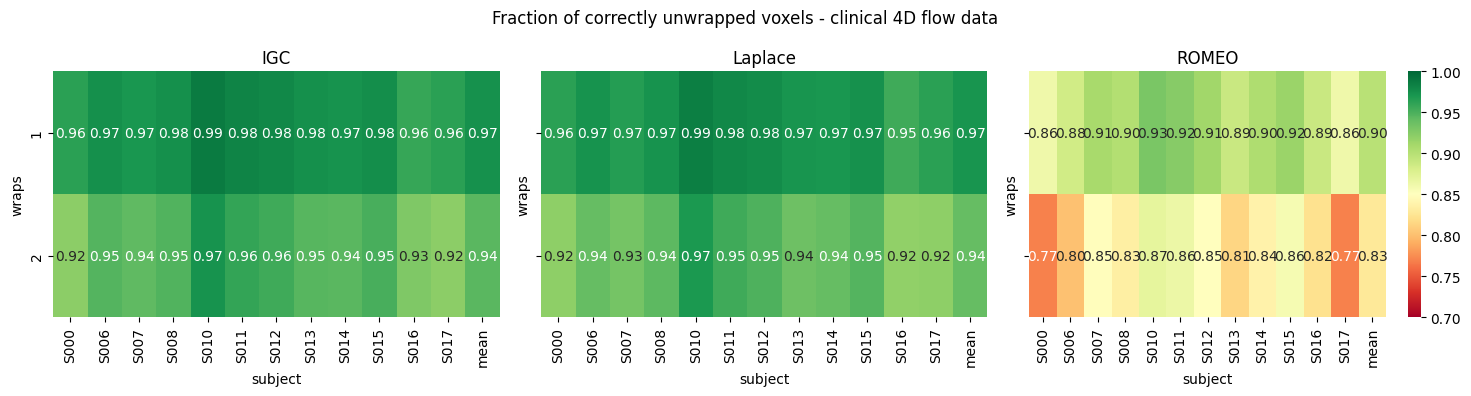

In [24]:
fig, axes = plt.subplots(1, len(clin_heatmaps), figsize=(5 * len(clin_heatmaps), 4), sharey=True)

for axis, (algorithm, heatmap_df) in zip(axes, clin_heatmaps.items()):
    sn.heatmap(heatmap_df, annot=True, fmt=".2f", vmin=0.7, vmax=1.0,
               cmap="RdYlGn", cbar=axis is axes[-1], ax=axis)
    axis.set_title(algorithm)

fig.suptitle("Fraction of correctly unwrapped voxels - clinical 4D flow data")
fig.tight_layout()
